# Gap-filling modelling focus

This notebook starts from the existing prepared modelling data. It does **not** rebuild the upstream meteorological or management preprocessing.

The first objective is to understand the temporal structure that the final gap-filling evaluation must respect:

1. load and audit the prepared data;
2. characterise real missingness and gap durations;
3. perform focused classical time-series analysis (TSA);
4. use TICA to identify slow, multivariate environmental states.

MDS, RFm, TabICL and later candidate models will follow these diagnostic sections.

## 0. Setup

In [1]:
from pathlib import Path
import time
import hashlib
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import lombscargle
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf, pacf

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

TOWERS = [2, 4, 9]
TOWER_COLORS = {2: "#4C72B0", 4: "#DD8452", 9: "#55A868"}
DOMAIN = {
    2: ("2017-10-01", "2019-06-30"),
    4: ("2017-10-01", "2023-12-31"),
    9: ("2020-02-01", "2023-12-31"),
}

# Support launching Jupyter from either this notebook directory or the repository root.
NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "_data_gf_training").exists():
    repo_relative = Path("notebooks/03c_gap_filling_revisited")
    if (repo_relative / "_data_gf_training").exists():
        NOTEBOOK_DIR = repo_relative

SPLIT_DIR = NOTEBOOK_DIR / "_data_gf_training/laglead_full_v2_split"
DATA_DIR = NOTEBOOK_DIR / "_data_focus"
CACHE_DIR = NOTEBOOK_DIR / "_model_cache_focus"
DATA_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

print(f"Notebook directory: {NOTEBOOK_DIR.resolve()}")
print("Setup complete.")

Notebook directory: C:\Users\Nicholas\Documents\COMP0191 MSc Artificial Intelligence for Sustainable Development Project\notebooks\03c_gap_filling_revisited
Setup complete.


## 1. Load and audit the prepared modelling data

The four CSV files are mutually exclusive partitions of the same prepared hourly frame:

- `train` and `test`: real, quality-controlled FCH4 observations;
- `to_gapfill`: genuine FCH4 gaps;
- `other_pre2018`: the small observed pre-2018 remainder.

They are recombined here because TSA and TICA require chronological trajectories. The `split` label is retained for later modelling.

In [2]:
SPLIT_FILES = {
    "train": "train.csv",
    "test": "test.csv",
    "to_gapfill": "to_gapfill.csv",
    "other_pre2018": "other_pre2018.csv",
}

parts = {}
schemas = {}
for split, filename in SPLIT_FILES.items():
    path = SPLIT_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing prepared split: {path.resolve()}")
    part = pd.read_csv(path, parse_dates=["Datetime"], low_memory=False)
    part["split"] = split
    parts[split] = part
    schemas[split] = set(part.columns) - {"split"}
    print(f"{split:>13}: {len(part):>7,} rows x {part.shape[1] - 1} prepared columns")

reference_schema = schemas["train"]
schema_mismatches = {name: sorted(cols ^ reference_schema) for name, cols in schemas.items() if cols != reference_schema}
assert not schema_mismatches, f"Split schemas differ: {schema_mismatches}"

prepared = (
    pd.concat(parts.values(), ignore_index=True)
    .sort_values(["tower", "Datetime"])
    .reset_index(drop=True)
)
prepared["tower"] = prepared["tower"].astype(int)

duplicate_keys = prepared.duplicated(["tower", "Datetime"], keep=False)
assert not duplicate_keys.any(), "Duplicate tower-hour rows found in the prepared split files."
assert set(prepared["tower"].unique()) == set(TOWERS)

print(f"\nCombined prepared frame: {prepared.shape[0]:,} rows x {prepared.shape[1]:,} columns")
prepared[["Datetime", "tower", "split", "target"]].head()

        train:  21,998 rows x 167 prepared columns
         test:  12,949 rows x 167 prepared columns
   to_gapfill:  68,769 rows x 167 prepared columns
other_pre2018:     639 rows x 167 prepared columns

Combined prepared frame: 104,355 rows x 168 columns


,Datetime,tower,split,target
0,2017-10-01 00:00:00,2,to_gapfill,NaN
1,2017-10-01 01:00:00,2,to_gapfill,NaN
2,2017-10-01 02:00:00,2,to_gapfill,NaN
3,2017-10-01 03:00:00,2,to_gapfill,NaN
4,2017-10-01 04:00:00,2,to_gapfill,NaN


### 1.1 Restore the complete hourly domain

Rows absent from all four files are explicitly restored as empty hours. This makes timestamp discontinuities visible and prevents lagged analyses from silently treating non-adjacent observations as neighbours.

In [3]:
def domain_index(tower):
    start, final_day = DOMAIN[tower]
    # DOMAIN final dates are inclusive midnight timestamps in the prepared export.
    # Adding 23 hours creates 23 artificial absent rows at the end of every tower.
    end = pd.Timestamp(final_day)
    return pd.date_range(start=start, end=end, freq="h", name="Datetime")


tower_hourly = {}
audit_rows = []

for tower in TOWERS:
    original = prepared.loc[prepared["tower"].eq(tower)].set_index("Datetime").sort_index()
    expected_index = domain_index(tower)
    hourly = original.reindex(expected_index)
    hourly["tower"] = tower
    hourly["split"] = hourly["split"].fillna("absent")
    tower_hourly[tower] = hourly

    n_expected = len(expected_index)
    n_present = int(hourly["split"].ne("absent").sum())
    n_observed = int(hourly["target"].notna().sum())
    audit_rows.append({
        "tower": tower,
        "domain_start": expected_index.min(),
        "domain_end": expected_index.max(),
        "expected_hours": n_expected,
        "rows_in_files": n_present,
        "absent_rows": n_expected - n_present,
        "FCH4_observed": n_observed,
        "FCH4_missing": n_expected - n_observed,
        "FCH4_coverage_pct": 100 * n_observed / n_expected,
    })

DATA_AUDIT = pd.DataFrame(audit_rows).set_index("tower")
DATA_AUDIT.round({"FCH4_coverage_pct": 1})

,domain_start,domain_end,expected_hours,rows_in_files,absent_rows,FCH4_observed,FCH4_missing,FCH4_coverage_pct
tower,,,,,,,,
2,2017-10-01,2019-06-30,15289,15289,0,4890,10399,32.0
4,2017-10-01,2023-12-31,54769,54769,0,19465,35304,35.5
9,2020-02-01,2023-12-31,34297,34297,0,11231,23066,32.7


In [4]:
# Predictor completeness is assessed on rows that exist in the prepared files.
excluded_from_predictor_audit = {"Datetime", "target", "tower", "split"}
candidate_predictors = [c for c in prepared.columns if c not in excluded_from_predictor_audit]

predictor_missingness = pd.DataFrame({
    tower: 100 * tower_hourly[tower].loc[
        tower_hourly[tower]["split"].ne("absent"), candidate_predictors
    ].isna().mean()
    for tower in TOWERS
})
predictor_missingness.columns = [f"T{tower}_missing_pct" for tower in TOWERS]
predictor_missingness["max_missing_pct"] = predictor_missingness.max(axis=1)

print("Predictors with the greatest remaining missingness:")
predictor_missingness.sort_values("max_missing_pct", ascending=False).head(20).round(2)

Predictors with the greatest remaining missingness:


,T2_missing_pct,T4_missing_pct,T9_missing_pct,max_missing_pct
target_leadQ672,69.27,64.81,67.48,69.27
target_leadQ504,68.95,64.70,67.46,68.95
target_leadQ336,68.77,64.66,67.35,68.77
target_leadQ168,68.12,64.49,67.27,68.12
target_lagQ672,68.02,64.95,68.08,68.08
target_leadQ1,68.02,64.46,67.25,68.02
target_leadQ2,68.02,64.46,67.25,68.02
target_leadQ3,68.02,64.46,67.25,68.02
target_leadQ6,68.02,64.46,67.25,68.02
target_leadQ24,68.02,64.46,67.25,68.02


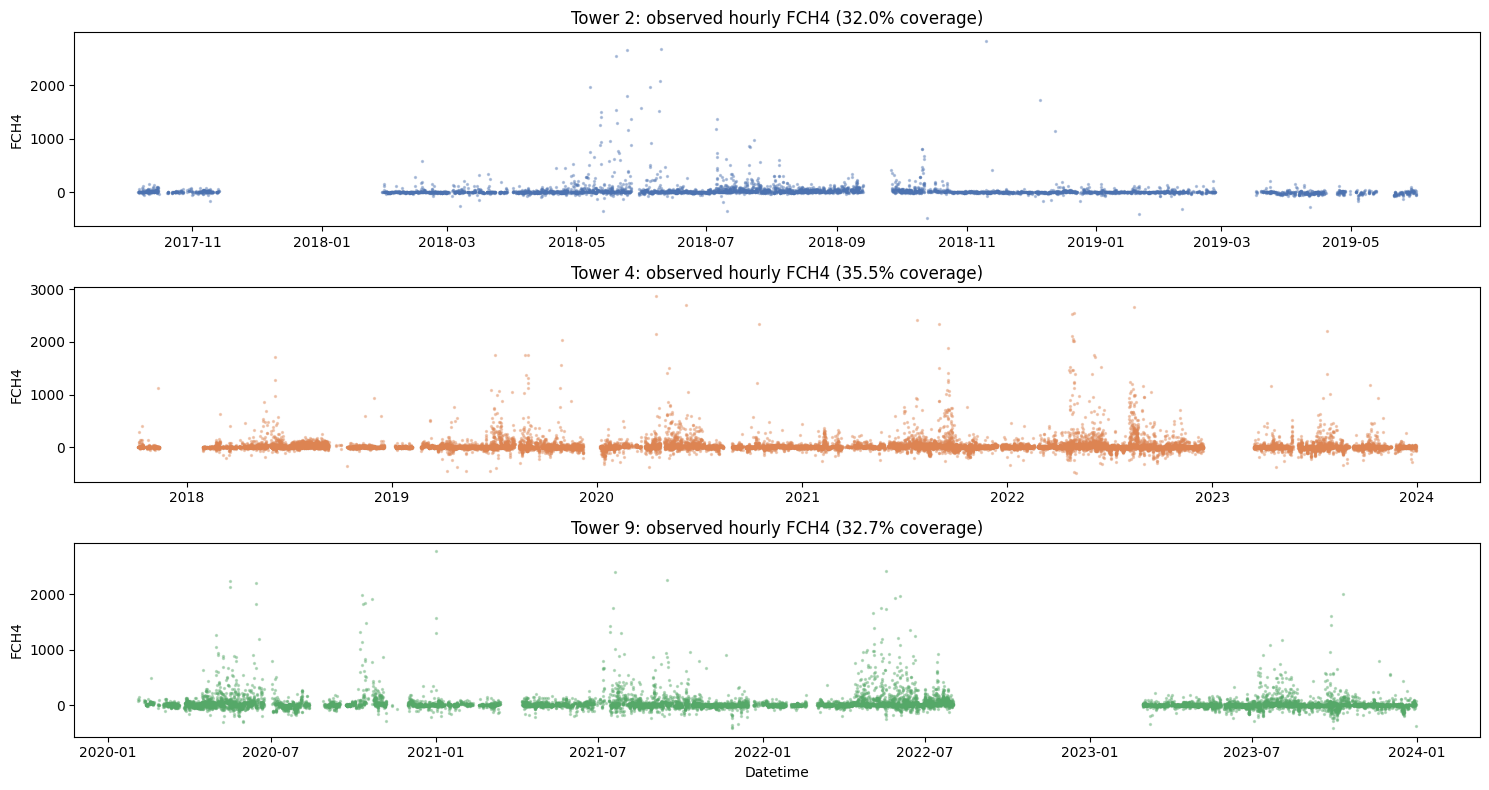

In [5]:
fig, axes = plt.subplots(len(TOWERS), 1, figsize=(15, 8), sharex=False)
for ax, tower in zip(axes, TOWERS):
    series = tower_hourly[tower]["target"]
    ax.scatter(series.index, series, s=2, alpha=0.35, color=TOWER_COLORS[tower], rasterized=True)
    ax.set_title(f"Tower {tower}: observed hourly FCH4 ({series.notna().mean():.1%} coverage)")
    ax.set_ylabel("FCH4")
axes[-1].set_xlabel("Datetime")
plt.tight_layout()
plt.show()

## 2. Missingness and gap-duration analysis

Real missingness is the application domain of the gap-filling models. Gap runs are calculated on the complete hourly domain, so completely absent rows and rows labelled `to_gapfill` are both counted as missing target hours.

In [6]:
def missing_runs(series):
    """Return consecutive missing runs from a regularly indexed Series."""
    missing = series.isna()
    run_id = missing.ne(missing.shift(fill_value=False)).cumsum()
    tmp = pd.DataFrame({
        "Datetime": series.index,
        "missing": missing.to_numpy(),
        "run_id": run_id.to_numpy(),
    })
    return (
        tmp.loc[tmp["missing"]]
        .groupby("run_id", as_index=False)
        .agg(start=("Datetime", "min"), end=("Datetime", "max"), n_hours=("missing", "size"))
        .drop(columns="run_id")
    )


gap_tables = {}
for tower in TOWERS:
    gaps = missing_runs(tower_hourly[tower]["target"])
    gaps["tower"] = tower
    gap_tables[tower] = gaps

REAL_GAPS = pd.concat(gap_tables.values(), ignore_index=True)
REAL_GAPS["duration_class"] = pd.cut(
    REAL_GAPS["n_hours"],
    bins=[0, 1, 4, 32, 288, np.inf],
    labels=["1 h", "2–4 h", "5–32 h", "33–288 h", ">288 h"],
)

GAP_SUMMARY = REAL_GAPS.groupby("tower")["n_hours"].agg(
    gap_count="size",
    missing_hours="sum",
    median_gap="median",
    p90_gap=lambda x: x.quantile(0.90),
    maximum_gap="max",
)
GAP_SUMMARY

,gap_count,missing_hours,median_gap,p90_gap,maximum_gap
tower,,,,,
2,2046,10399,2.0,7.0,1847
4,8069,35304,2.0,7.0,2166
9,4639,23066,2.0,7.0,5079


duration_class,1 h,2–4 h,5–32 h,33–288 h,>288 h
tower,,,,,
2,972,739,317,14,4
4,3728,2990,1279,65,7
9,2208,1693,691,43,4


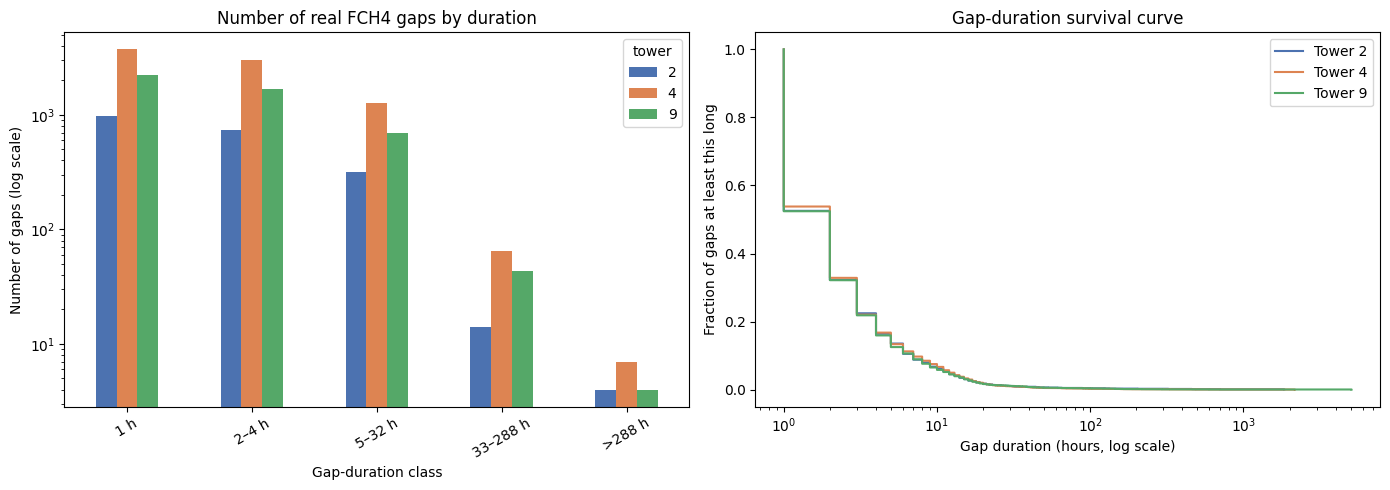

In [7]:
gap_class_counts = (
    REAL_GAPS.groupby(["tower", "duration_class"], observed=False)
    .size()
    .unstack(fill_value=0)
)
display(gap_class_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gap_class_counts.T.plot(kind="bar", ax=axes[0], color=[TOWER_COLORS[t] for t in TOWERS])
axes[0].set_yscale("log")
axes[0].set_title("Number of real FCH4 gaps by duration")
axes[0].set_xlabel("Gap-duration class")
axes[0].set_ylabel("Number of gaps (log scale)")
axes[0].tick_params(axis="x", rotation=30)

for tower in TOWERS:
    durations = np.sort(gap_tables[tower]["n_hours"].to_numpy())
    survival = 1 - np.arange(len(durations)) / len(durations)
    axes[1].step(durations, survival, where="post", color=TOWER_COLORS[tower], label=f"Tower {tower}")
axes[1].set_xscale("log")
axes[1].set_title("Gap-duration survival curve")
axes[1].set_xlabel("Gap duration (hours, log scale)")
axes[1].set_ylabel("Fraction of gaps at least this long")
axes[1].legend()

plt.tight_layout()
plt.show()

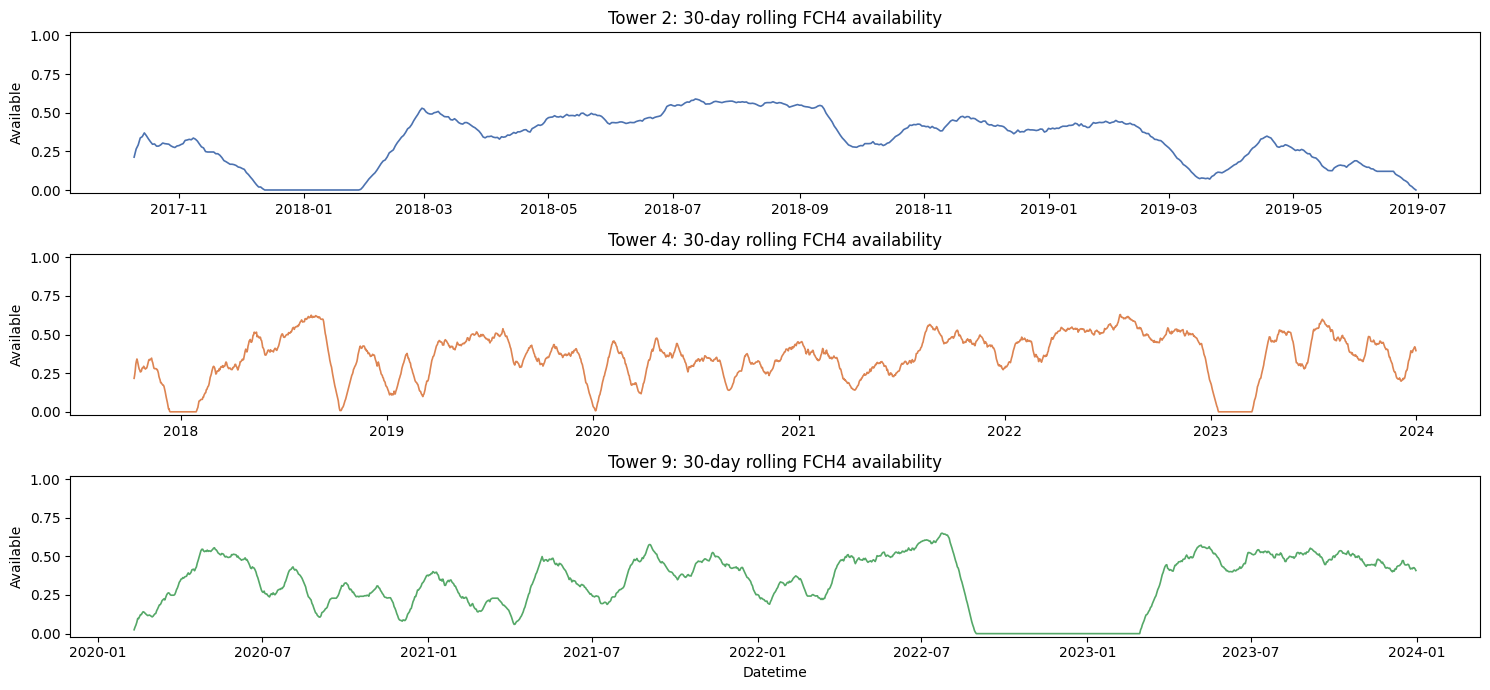

In [8]:
fig, axes = plt.subplots(len(TOWERS), 1, figsize=(15, 7), sharex=False, sharey=True)
for ax, tower in zip(axes, TOWERS):
    daily_availability = tower_hourly[tower]["target"].notna().resample("D").mean()
    ax.plot(daily_availability.index, daily_availability.rolling(30, min_periods=10).mean(),
            color=TOWER_COLORS[tower], linewidth=1.2)
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel("Available")
    ax.set_title(f"Tower {tower}: 30-day rolling FCH4 availability")
axes[-1].set_xlabel("Datetime")
plt.tight_layout()
plt.show()

## 3. Classical time-series analysis

The target is highly incomplete: its longest uninterrupted observed run is only about one day. Consequently:

- long target gaps are **not** interpolated for TSA;
- hourly autocorrelation is estimated from valid timestamp pairs at each lag;
- STL and PACF are performed at daily resolution, requiring at least six observed hours per daily mean and interpolating only internal gaps of at most two days;
- the Lomb–Scargle periodogram is used because it supports irregularly observed targets.

These are exploratory diagnostics, not model validation.

### 3.1 Trend and seasonal structure

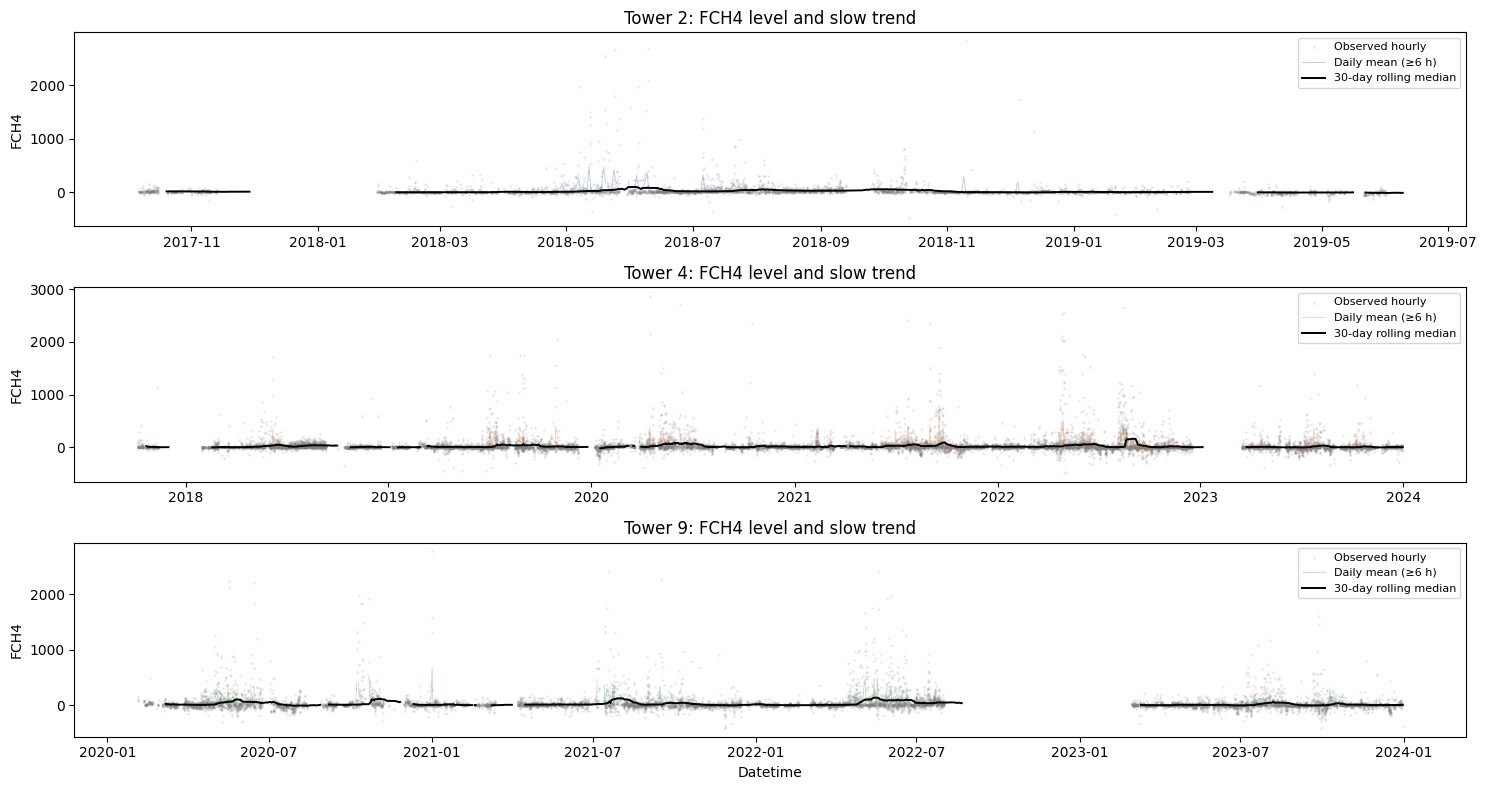

In [9]:
MIN_HOURS_PER_DAY = 6

daily_target = {}
fig, axes = plt.subplots(len(TOWERS), 1, figsize=(15, 8), sharex=False)

for ax, tower in zip(axes, TOWERS):
    target = tower_hourly[tower]["target"]
    daily = target.resample("D").agg(["mean", "count"])
    daily["adequately_sampled_mean"] = daily["mean"].where(daily["count"] >= MIN_HOURS_PER_DAY)
    daily["rolling_30d_median"] = daily["adequately_sampled_mean"].rolling(30, min_periods=10).median()
    daily_target[tower] = daily

    ax.scatter(target.index, target, s=1, alpha=0.12, color="0.5", rasterized=True, label="Observed hourly")
    ax.plot(daily.index, daily["adequately_sampled_mean"], color=TOWER_COLORS[tower], alpha=0.35,
            linewidth=0.7, label=f"Daily mean (≥{MIN_HOURS_PER_DAY} h)")
    ax.plot(daily.index, daily["rolling_30d_median"], color="black", linewidth=1.4, label="30-day rolling median")
    ax.set_title(f"Tower {tower}: FCH4 level and slow trend")
    ax.set_ylabel("FCH4")
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Datetime")
plt.tight_layout()
plt.show()

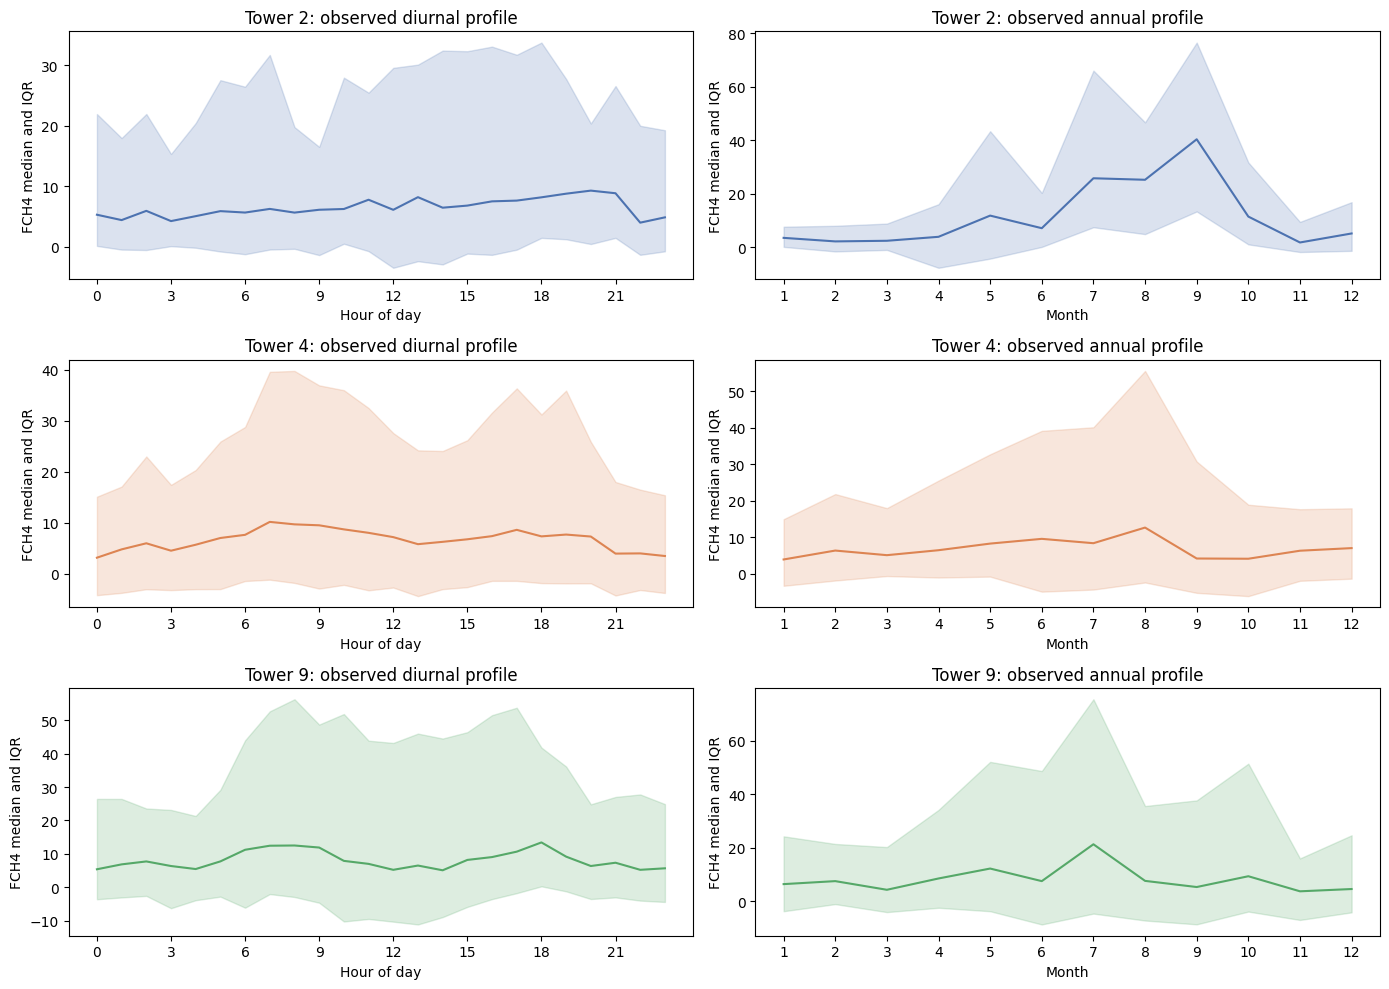

In [10]:
fig, axes = plt.subplots(len(TOWERS), 2, figsize=(14, 10))

for row, tower in enumerate(TOWERS):
    observed = tower_hourly[tower]["target"].dropna()
    profile_frame = pd.DataFrame({
        "target": observed,
        "hour": observed.index.hour,
        "month": observed.index.month,
    })

    hourly_profile = profile_frame.groupby("hour")["target"].agg(
        median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
    )
    monthly_profile = profile_frame.groupby("month")["target"].agg(
        median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
    )

    ax = axes[row, 0]
    ax.plot(hourly_profile.index, hourly_profile["median"], color=TOWER_COLORS[tower])
    ax.fill_between(hourly_profile.index, hourly_profile["q25"], hourly_profile["q75"],
                    color=TOWER_COLORS[tower], alpha=0.2)
    ax.set_title(f"Tower {tower}: observed diurnal profile")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("FCH4 median and IQR")
    ax.set_xticks(range(0, 24, 3))

    ax = axes[row, 1]
    ax.plot(monthly_profile.index, monthly_profile["median"], color=TOWER_COLORS[tower])
    ax.fill_between(monthly_profile.index, monthly_profile["q25"], monthly_profile["q75"],
                    color=TOWER_COLORS[tower], alpha=0.2)
    ax.set_title(f"Tower {tower}: observed annual profile")
    ax.set_xlabel("Month")
    ax.set_ylabel("FCH4 median and IQR")
    ax.set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

#### Limited daily STL decomposition

STL cannot accept missing values. For each tower, the series below uses adequately sampled daily means, fills only internal gaps of at most two consecutive days, and then selects the longest remaining continuous segment. The seven-day seasonal component is therefore a local diagnostic; it is not a reconstructed full target history.

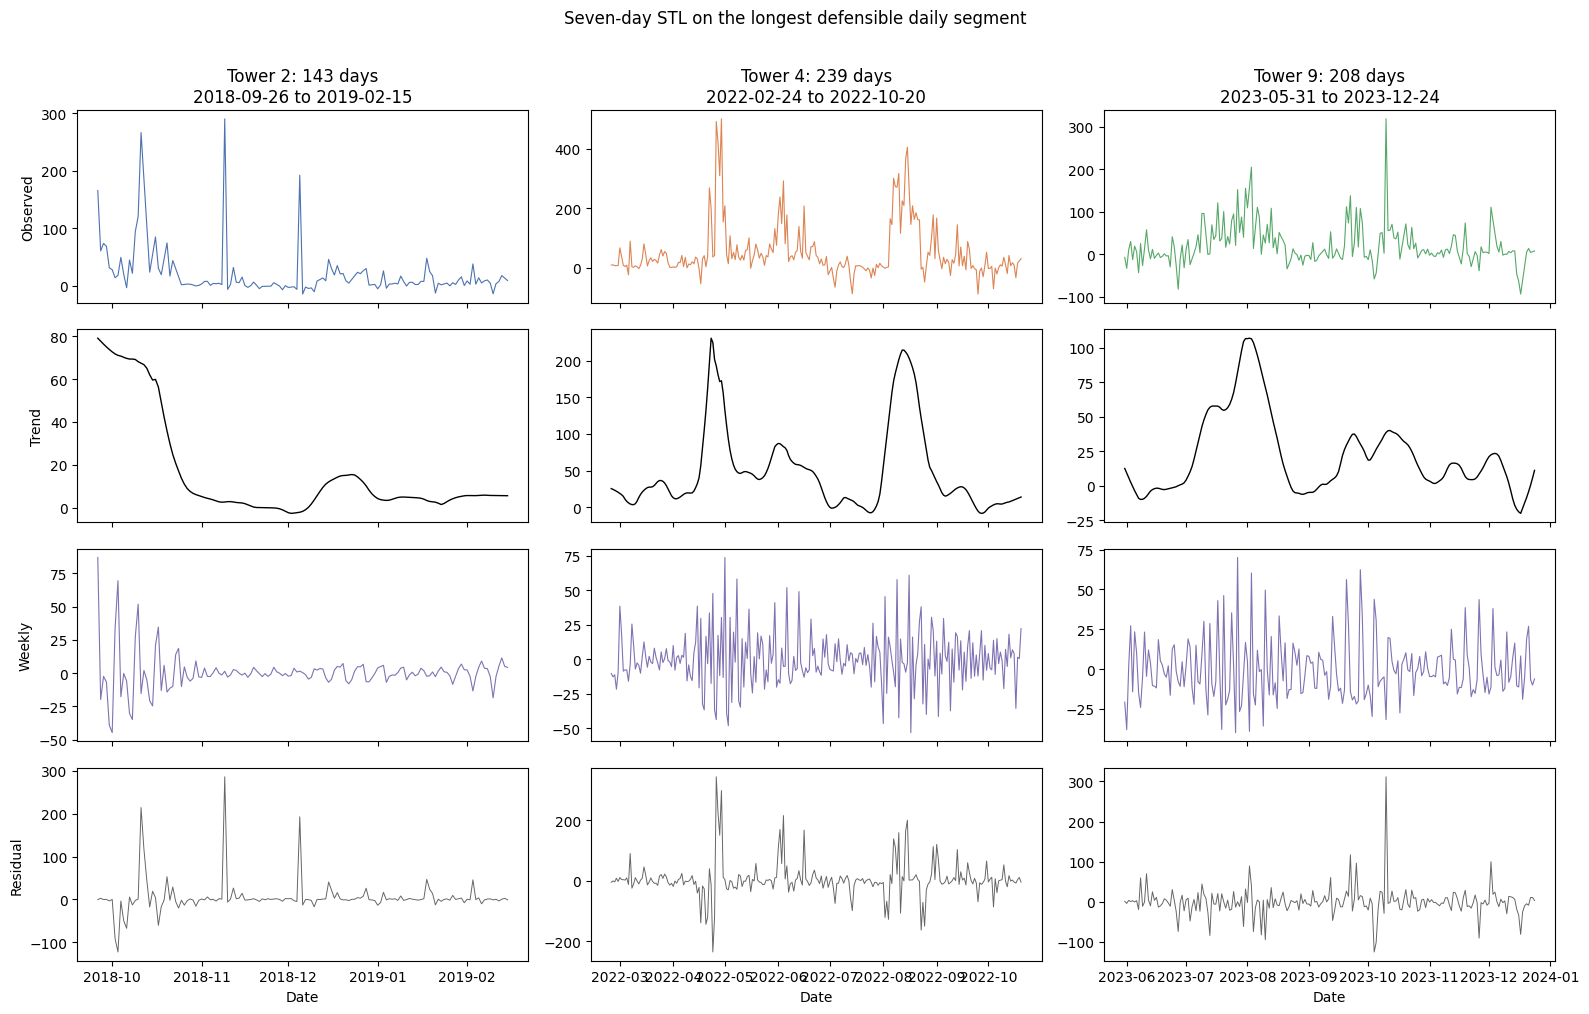

In [11]:
def longest_finite_segment(series):
    finite = series.notna()
    run_id = finite.ne(finite.shift(fill_value=False)).cumsum()
    segments = [segment for _, segment in series.loc[finite].groupby(run_id.loc[finite])]
    if not segments:
        return pd.Series(dtype=float)
    return max(segments, key=len)


daily_tsa_segments = {}
stl_results = {}
fig, axes = plt.subplots(4, len(TOWERS), figsize=(16, 10), sharex="col")

for col, tower in enumerate(TOWERS):
    limited_fill = daily_target[tower]["adequately_sampled_mean"].interpolate(
        limit=2, limit_area="inside"
    )
    segment = longest_finite_segment(limited_fill)
    if len(segment) < 21:
        raise ValueError(f"Tower {tower} has only {len(segment)} usable daily observations for weekly STL.")

    result = STL(segment, period=7, robust=True).fit()
    daily_tsa_segments[tower] = segment
    stl_results[tower] = result

    axes[0, col].plot(segment.index, result.observed, color=TOWER_COLORS[tower], linewidth=0.8)
    axes[1, col].plot(segment.index, result.trend, color="black", linewidth=1.0)
    axes[2, col].plot(segment.index, result.seasonal, color="#8172B2", linewidth=0.8)
    axes[3, col].plot(segment.index, result.resid, color="0.4", linewidth=0.7)
    axes[0, col].set_title(
        f"Tower {tower}: {len(segment)} days\n{segment.index.min().date()} to {segment.index.max().date()}"
    )

for row, label in enumerate(["Observed", "Trend", "Weekly", "Residual"]):
    axes[row, 0].set_ylabel(label)
for ax in axes[-1]:
    ax.set_xlabel("Date")

plt.suptitle("Seven-day STL on the longest defensible daily segment", y=1.01)
plt.tight_layout()
plt.show()

### 3.2 ACF and PACF

The hourly ACF below is a pairwise-complete correlation at each true hourly lag. It reports the number of usable pairs because that number changes with lag and missingness. Its usual textbook confidence interval does not apply directly.

A conventional PACF requires a continuous series, so PACF is shown for the limited daily segments used by STL. It should be interpreted in **days**, not hours.

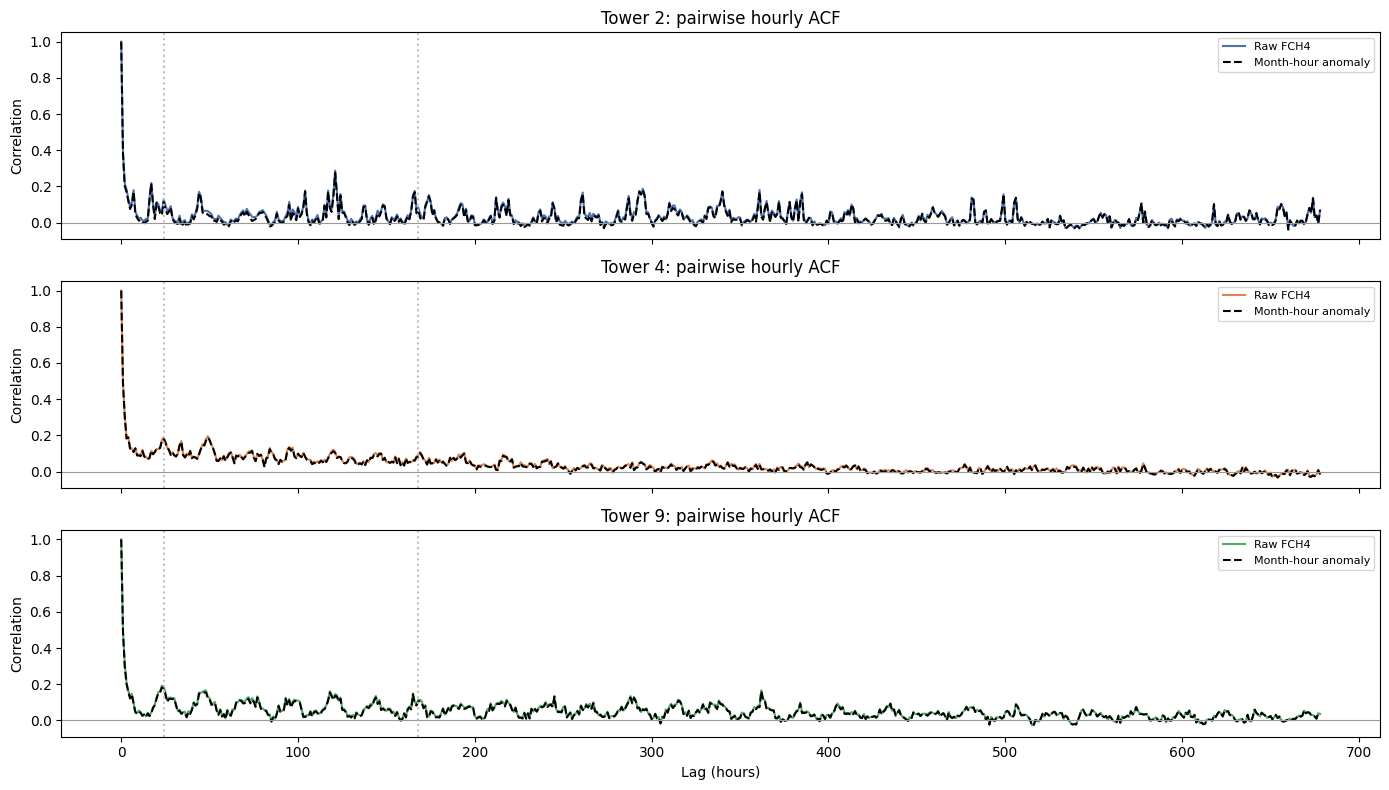

,tower,lag_hours,raw_acf,anomaly_acf,n_pairs
0,2,1,0.392,0.380,2845
1,2,6,0.113,0.100,2361
2,2,24,0.130,0.114,2327
3,2,168,0.084,0.069,2144
4,4,1,0.489,0.486,11397
5,4,6,0.129,0.129,9484
6,4,24,0.188,0.182,9277
7,4,168,0.089,0.082,8544
8,9,1,0.497,0.490,6593
9,9,6,0.147,0.144,5558


In [12]:
def month_hour_anomaly(series):
    """Remove the median month-by-hour climatology while retaining the hourly index."""
    frame = pd.DataFrame({
        "value": series,
        "month": series.index.month,
        "hour": series.index.hour,
    })
    climatology = frame.groupby(["month", "hour"])["value"].transform("median")
    return frame["value"] - climatology


def pairwise_acf(series, nlags=678):
    values = series.to_numpy(dtype=float)
    rows = []
    for lag in range(nlags + 1):
        left = values if lag == 0 else values[:-lag]
        right = values if lag == 0 else values[lag:]
        valid = np.isfinite(left) & np.isfinite(right)
        correlation = np.corrcoef(left[valid], right[valid])[0, 1] if valid.sum() >= 3 else np.nan
        rows.append({"lag_hours": lag, "acf": correlation, "n_pairs": int(valid.sum())})
    return pd.DataFrame(rows).set_index("lag_hours")


hourly_acf = {}
acf_pair_rows = []
fig, axes = plt.subplots(len(TOWERS), 1, figsize=(14, 8), sharex=True, sharey=True)

for ax, tower in zip(axes, TOWERS):
    raw = pairwise_acf(tower_hourly[tower]["target"], nlags=678)
    anomaly = pairwise_acf(month_hour_anomaly(tower_hourly[tower]["target"]), nlags=678)
    hourly_acf[tower] = {"raw": raw, "anomaly": anomaly}

    ax.plot(raw.index, raw["acf"], color=TOWER_COLORS[tower], label="Raw FCH4")
    ax.plot(anomaly.index, anomaly["acf"], color="black", linestyle="--", label="Month-hour anomaly")
    ax.axhline(0, color="0.6", linewidth=0.8)
    ax.axvline(24, color="0.75", linestyle=":")
    ax.axvline(168, color="0.75", linestyle=":")
    ax.set_title(f"Tower {tower}: pairwise hourly ACF")
    ax.set_ylabel("Correlation")
    ax.legend(fontsize=8)

    for lag in [1, 6, 24, 168]:
        acf_pair_rows.append({
            "tower": tower,
            "lag_hours": lag,
            "raw_acf": raw.loc[lag, "acf"],
            "anomaly_acf": anomaly.loc[lag, "acf"],
            "n_pairs": int(raw.loc[lag, "n_pairs"]),
        })

axes[-1].set_xlabel("Lag (hours)")
plt.tight_layout()
plt.show()

ACF_KEY_LAGS = pd.DataFrame(acf_pair_rows)
ACF_KEY_LAGS.round(3)

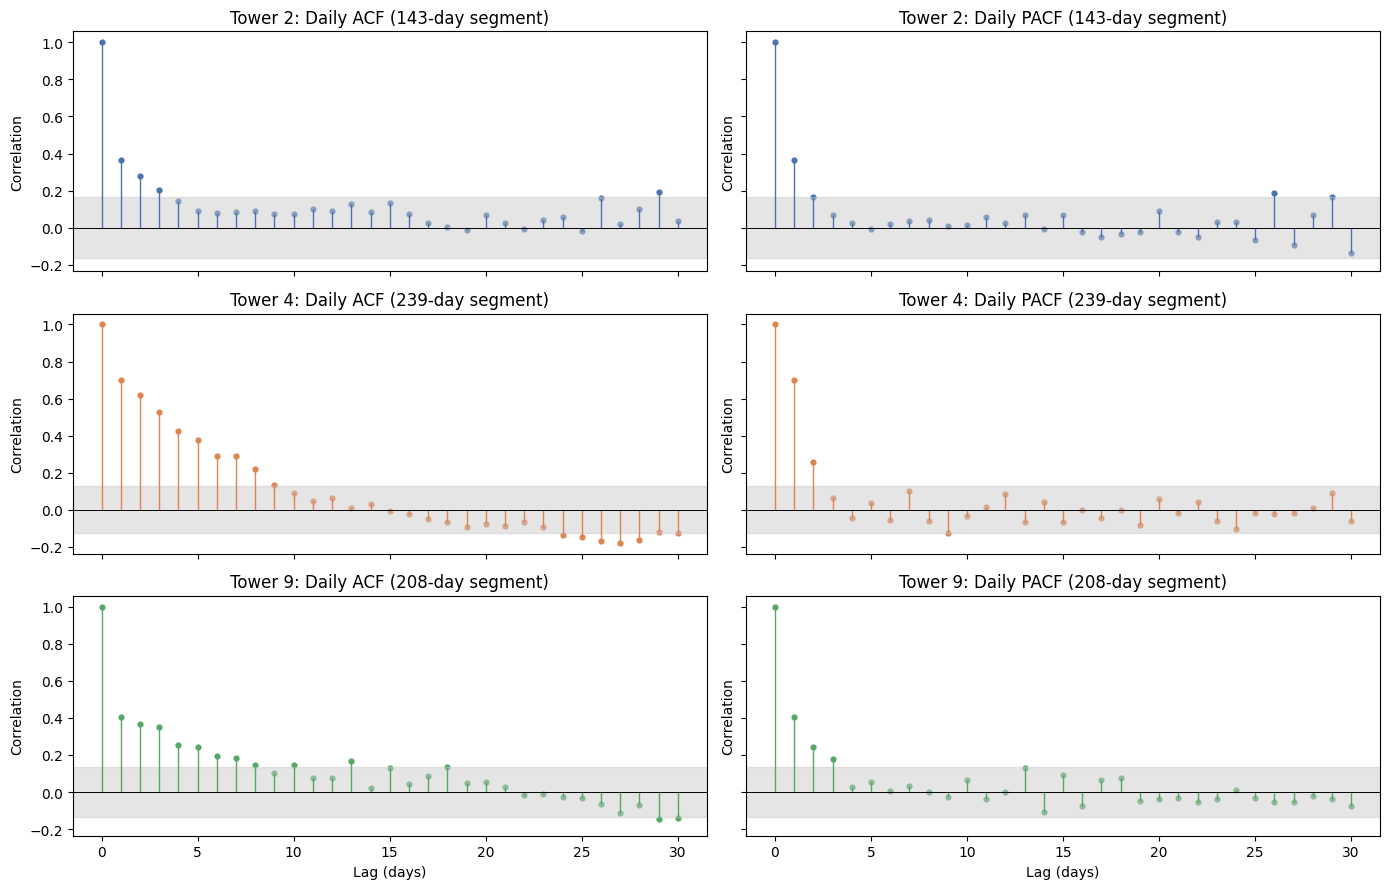

In [13]:
fig, axes = plt.subplots(len(TOWERS), 2, figsize=(14, 9), sharex=True, sharey=True)

for row, tower in enumerate(TOWERS):
    segment = daily_tsa_segments[tower]
    nlags = min(30, len(segment) // 2 - 1)
    daily_acf_values = acf(segment, nlags=nlags, fft=True)
    daily_pacf_values = pacf(segment, nlags=nlags, method="ywm")
    approximate_ci = 1.96 / np.sqrt(len(segment))

    for col, (values, title) in enumerate([
        (daily_acf_values, "Daily ACF"),
        (daily_pacf_values, "Daily PACF"),
    ]):
        ax = axes[row, col]
        lags = np.arange(len(values))
        ax.vlines(lags, 0, values, color=TOWER_COLORS[tower], linewidth=1)
        ax.scatter(lags, values, color=TOWER_COLORS[tower], s=12)
        ax.axhline(0, color="black", linewidth=0.7)
        ax.axhspan(-approximate_ci, approximate_ci, color="0.8", alpha=0.5)
        ax.set_title(f"Tower {tower}: {title} ({len(segment)}-day segment)")
        ax.set_ylabel("Correlation")

axes[-1, 0].set_xlabel("Lag (days)")
axes[-1, 1].set_xlabel("Lag (days)")
plt.tight_layout()
plt.show()

### 3.3 Spectral analysis

A Lomb–Scargle periodogram is used instead of filling the target onto a complete series. It tests periodic structure using the actual observation times. The target is linearly detrended first; peaks remain exploratory because environmental time series are autocorrelated and non-stationary.

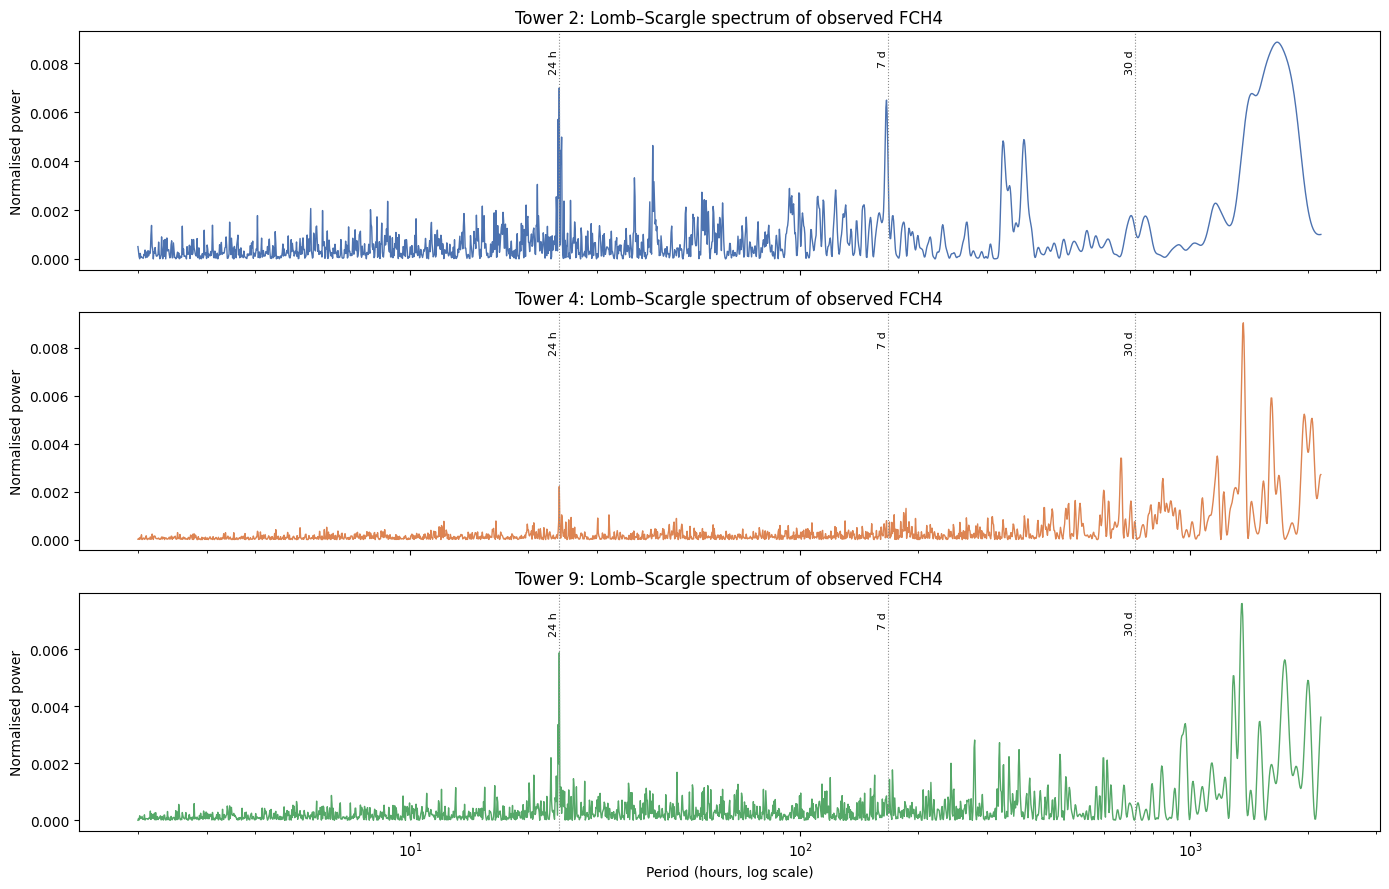

In [14]:
MIN_PERIOD_HOURS = 2
MAX_PERIOD_HOURS = 24 * 90
PERIOD_GRID = np.geomspace(MIN_PERIOD_HOURS, MAX_PERIOD_HOURS, 2000)

spectra = {}
fig, axes = plt.subplots(len(TOWERS), 1, figsize=(14, 9), sharex=True)

for ax, tower in zip(axes, TOWERS):
    observed = tower_hourly[tower]["target"].dropna()
    time_hours = (observed.index - observed.index.min()).total_seconds().to_numpy() / 3600
    values = observed.to_numpy(dtype=float)

    linear_trend = np.polyval(np.polyfit(time_hours, values, deg=1), time_hours)
    detrended = values - linear_trend

    # scipy is given increasing angular frequencies; reverse the output back to increasing periods.
    angular_frequency = 2 * np.pi / PERIOD_GRID[::-1]
    power = lombscargle(time_hours, detrended, angular_frequency, precenter=True, normalize=True)[::-1]
    spectra[tower] = pd.Series(power, index=PERIOD_GRID, name="power")

    ax.plot(PERIOD_GRID, power, color=TOWER_COLORS[tower], linewidth=1)
    for period, label in [(24, "24 h"), (168, "7 d"), (24 * 30, "30 d")]:
        ax.axvline(period, color="0.55", linestyle=":", linewidth=0.8)
        ax.text(period, ax.get_ylim()[1] * 0.92, label, rotation=90, va="top", ha="right", fontsize=8)
    ax.set_xscale("log")
    ax.set_title(f"Tower {tower}: Lomb–Scargle spectrum of observed FCH4")
    ax.set_ylabel("Normalised power")

axes[-1].set_xlabel("Period (hours, log scale)")
plt.tight_layout()
plt.show()

### 3.4 Predictor–target cross-correlations

Both target and predictor are converted to month-by-hour anomalies before correlation. For the convention below, a **positive lag means the predictor occurred before FCH4**. Cross-correlation is exploratory: shared residual seasonality and serial dependence can still produce apparently strong peaks.

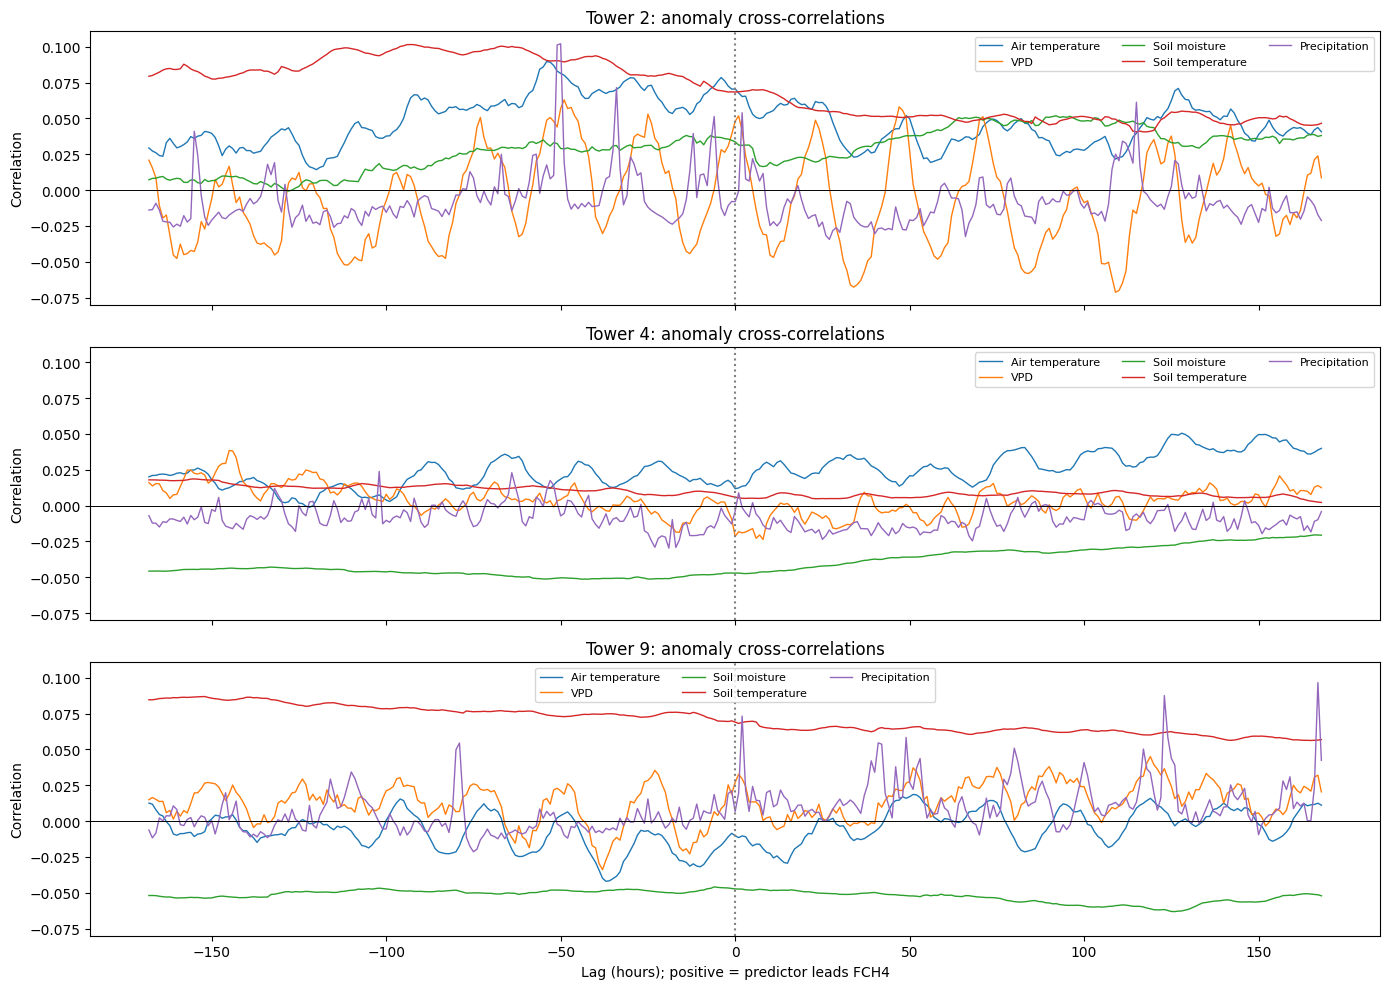

,tower,predictor,peak_lag_hours,correlation_at_peak,n_pairs
0,2,Air temperature,-54,0.090,4890
1,2,VPD,109,-0.071,4890
2,2,Soil moisture,92,0.052,4890
3,2,Soil temperature,-93,0.102,4890
4,2,Precipitation,-50,0.102,4890
5,4,Air temperature,128,0.051,19465
6,4,VPD,-145,0.038,19413
7,4,Soil moisture,-44,-0.051,19455
8,4,Soil temperature,-155,0.019,19413
9,4,Precipitation,-19,-0.030,19462


In [15]:
CCF_FEATURES = {
    "Air temperature": "TA_0_0_1",
    "VPD": "VPD_0_0_1",
    "Soil moisture": "Soil Moisture @ 10cm Depth (%)",
    "Soil temperature": "Soil Temperature @ 15cm Depth (oC)",
    "Precipitation": "Precipitation (mm)",
}
missing_ccf_features = [column for column in CCF_FEATURES.values() if column not in prepared.columns]
assert not missing_ccf_features, f"Missing cross-correlation predictors: {missing_ccf_features}"


def lagged_pairwise_correlation(target, predictor, lags):
    rows = []
    for lag in lags:
        # shift(+k) aligns predictor[t-k] with target[t].
        shifted_predictor = predictor.shift(lag)
        valid = target.notna() & shifted_predictor.notna()
        correlation = target.loc[valid].corr(shifted_predictor.loc[valid]) if valid.sum() >= 3 else np.nan
        rows.append({"lag_hours": lag, "correlation": correlation, "n_pairs": int(valid.sum())})
    return pd.DataFrame(rows).set_index("lag_hours")


CCF_LAGS = np.arange(-168, 169)
cross_correlations = {}
peak_rows = []
fig, axes = plt.subplots(len(TOWERS), 1, figsize=(14, 10), sharex=True, sharey=True)

for ax, tower in zip(axes, TOWERS):
    frame = tower_hourly[tower]
    target_anomaly = month_hour_anomaly(frame["target"])
    cross_correlations[tower] = {}

    for label, column in CCF_FEATURES.items():
        predictor_anomaly = month_hour_anomaly(frame[column])
        ccf = lagged_pairwise_correlation(target_anomaly, predictor_anomaly, CCF_LAGS)
        cross_correlations[tower][label] = ccf
        ax.plot(ccf.index, ccf["correlation"], linewidth=1, label=label)

        peak_lag = int(ccf["correlation"].abs().idxmax())
        peak_rows.append({
            "tower": tower,
            "predictor": label,
            "peak_lag_hours": peak_lag,
            "correlation_at_peak": ccf.loc[peak_lag, "correlation"],
            "n_pairs": int(ccf.loc[peak_lag, "n_pairs"]),
        })

    ax.axhline(0, color="black", linewidth=0.7)
    ax.axvline(0, color="0.5", linestyle=":")
    ax.set_title(f"Tower {tower}: anomaly cross-correlations")
    ax.set_ylabel("Correlation")
    ax.legend(ncol=3, fontsize=8)

axes[-1].set_xlabel("Lag (hours); positive = predictor leads FCH4")
plt.tight_layout()
plt.show()

CCF_PEAKS = pd.DataFrame(peak_rows)
CCF_PEAKS.round(3)

## 4. Time-lagged independent component analysis (TICA)

TICA finds linear combinations of predictors that are maximally autocorrelated at lag $\tau$. It is used here first as exploratory dimensionality reduction—not as an imputation model.

Correctness rules:

- each tower is a separate trajectory;
- any missing predictor hour breaks a trajectory segment;
- `target`, target lags/leads, tower dummies and deterministic clock encodings are excluded;
- pre-expanded predictor lags/leads are excluded because TICA itself introduces the temporal lag;
- scaling is pooled across towers for this EDA only;
- if TICs later become model features, scaling and TICA must be refitted inside every CV training fold.

Reference: [deeptime TICA tutorial](https://deeptime-ml.github.io/latest/notebooks/tica.html).

### 4.1 Install and import `deeptime`

Run the installation cell once in this notebook's kernel. After a first installation, Jupyter may ask for a kernel restart.

In [16]:
%pip install --quiet deeptime==0.4.5

Note: you may need to restart the kernel to use updated packages.


In [17]:
import deeptime
from deeptime.decomposition import TICA

print("deeptime version:", deeptime.__version__)

deeptime version: 0.4.5


### 4.2 Define target-free feature spaces

The primary run uses contemporaneous meteorological and soil variables. A second, optional feature set adds reconstructed CO2/ecosystem and management variables; it is kept separate because slowly changing management clocks can dominate the leading TICs.

In [18]:
TICA_ENVIRONMENTAL = [
    "SWIN_1_1_1",
    "TA_0_0_1",
    "VPD_0_0_1",
    "PPFD_1_1_1",
    "RN_1_1_1",
    "WS_0_0_1",
    "USTAR_0_0_1",
    "SHF_1_1_1",
    "Precipitation (mm)",
    "Soil Temperature @ 15cm Depth (oC)",
    "Soil Moisture @ 10cm Depth (%)",
]

TICA_ENVIRONMENT_AND_MANAGEMENT = TICA_ENVIRONMENTAL + [
    "fc",
    "reco",
    "mgmt_cut",
    "mgmt_manure",
    "cattle_dens",
    "sheep_dens",
    "lamb_dens",
    "hours_since_graze_change",
]

TICA_FEATURE_SETS = {
    "environmental": TICA_ENVIRONMENTAL,
    "environment_and_management": TICA_ENVIRONMENT_AND_MANAGEMENT,
}

TICA_FEATURE_SET = "environmental"
TICA_FEATURES = TICA_FEATURE_SETS[TICA_FEATURE_SET]
TICA_LAGS = [1, 6, 24, 168]
N_TICS = 3

missing_tica_features = [column for column in TICA_FEATURES if column not in prepared.columns]
assert not missing_tica_features, f"Missing TICA predictors: {missing_tica_features}"
assert "target" not in TICA_FEATURES

print(f"TICA feature set: {TICA_FEATURE_SET} ({len(TICA_FEATURES)} predictors)")
print(*TICA_FEATURES, sep="\n  - ")

TICA feature set: environmental (11 predictors)
SWIN_1_1_1
  - TA_0_0_1
  - VPD_0_0_1
  - PPFD_1_1_1
  - RN_1_1_1
  - WS_0_0_1
  - USTAR_0_0_1
  - SHF_1_1_1
  - Precipitation (mm)
  - Soil Temperature @ 15cm Depth (oC)
  - Soil Moisture @ 10cm Depth (%)


### 4.3 Construct separate, contiguous tower trajectories

In [19]:
def contiguous_feature_segments(frame, features, min_length):
    """Split a regular hourly frame wherever any selected feature is non-finite."""
    values = frame[features].to_numpy(dtype=float)
    finite = pd.Series(np.isfinite(values).all(axis=1), index=frame.index)
    segment_id = (~finite).cumsum()
    segments = []
    for _, block in frame.loc[finite, features].groupby(segment_id.loc[finite]):
        if len(block) >= min_length:
            segments.append({
                "index": block.index,
                "X": block.to_numpy(dtype=float),
            })
    return segments


minimum_segment_length = max(TICA_LAGS) + 1
tica_segments = []
segment_rows = []

for tower in TOWERS:
    tower_segments = contiguous_feature_segments(
        tower_hourly[tower], TICA_FEATURES, min_length=minimum_segment_length
    )
    for segment_number, segment in enumerate(tower_segments, start=1):
        segment["tower"] = tower
        segment["segment"] = segment_number
        tica_segments.append(segment)
        segment_rows.append({
            "tower": tower,
            "segment": segment_number,
            "start": segment["index"].min(),
            "end": segment["index"].max(),
            "hours": len(segment["index"]),
        })

TICA_SEGMENT_AUDIT = pd.DataFrame(segment_rows)
assert len(tica_segments) > 0, "No sufficiently long, complete TICA trajectories were found."

# Pooled scaling is acceptable for this descriptive embedding. It is not CV-safe feature engineering.
tica_scaler = StandardScaler().fit(np.vstack([segment["X"] for segment in tica_segments]))
for segment in tica_segments:
    segment["X_scaled"] = tica_scaler.transform(segment["X"])

display(TICA_SEGMENT_AUDIT)
print(f"Total complete hours retained for TICA: {sum(row['hours'] for row in segment_rows):,}")

,tower,segment,start,end,hours
0,2,1,2017-10-01,2019-06-30,15289
1,4,1,2017-10-01,2023-12-31,54769
2,9,1,2020-02-01,2023-12-31,34297


Total complete hours retained for TICA: 104,355


### 4.4 Lag-time sensitivity

`partial_fit` accumulates lagged covariance pairs from each trajectory segment without joining tower boundaries. `scaling=None` keeps the TIC projections unscaled for straightforward interpretation; feature–component correlations are used as loadings.

In [20]:
tica_models = {}
tica_diagnostic_rows = []

for lag in TICA_LAGS:
    estimator = TICA(lagtime=lag, dim=N_TICS, scaling=None)
    n_pairs = 0

    for segment in tica_segments:
        X = segment["X_scaled"]
        if len(X) <= lag:
            continue
        estimator.partial_fit((X[:-lag], X[lag:]))
        n_pairs += len(X) - lag

    model = estimator.fetch_model()
    tica_models[lag] = model
    n_components = min(N_TICS, len(model.singular_values))
    timescales = model.timescales(k=n_components, lagtime=lag)

    for component in range(n_components):
        tica_diagnostic_rows.append({
            "lag_hours": lag,
            "component": f"TIC{component + 1}",
            "autocorrelation_strength": model.singular_values[component],
            "implied_timescale_hours": timescales[component],
            "n_lagged_pairs": n_pairs,
        })

TICA_DIAGNOSTICS = pd.DataFrame(tica_diagnostic_rows)
TICA_DIAGNOSTICS.round(3)

,lag_hours,component,autocorrelation_strength,implied_timescale_hours,n_lagged_pairs
0,1,TIC1,1.000,6777.788,104352
1,1,TIC2,0.999,1581.865,104352
2,1,TIC3,0.984,63.309,104352
3,6,TIC1,0.998,3867.512,104337
4,6,TIC2,0.991,701.392,104337
5,6,TIC3,0.842,34.936,104337
6,24,TIC1,0.994,4325.097,104283
7,24,TIC2,0.972,840.791,104283
8,24,TIC3,0.869,171.205,104283
9,168,TIC1,0.953,3501.064,103851


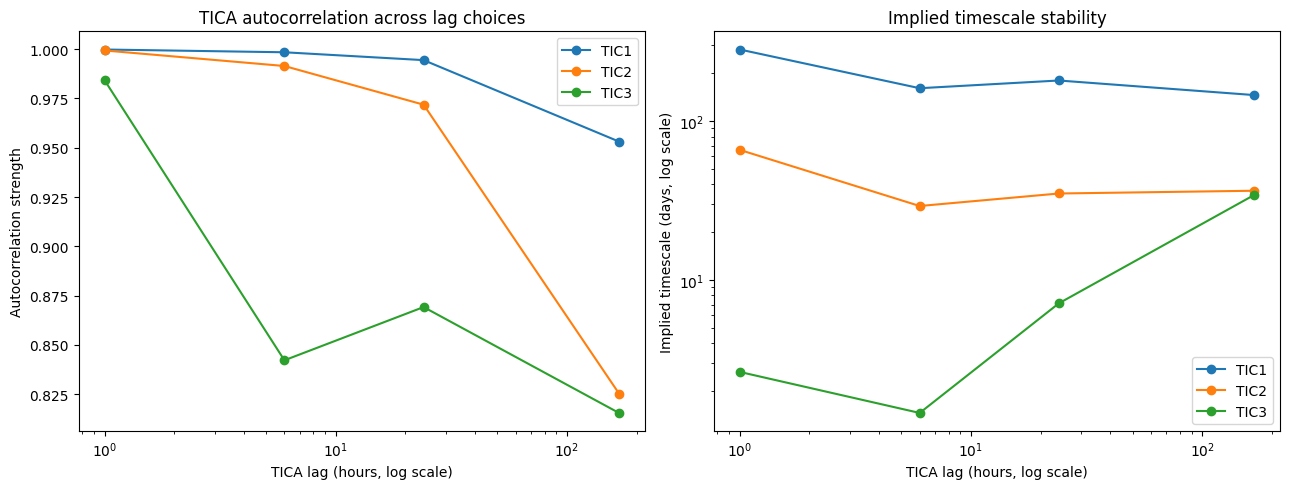

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for component, group in TICA_DIAGNOSTICS.groupby("component"):
    axes[0].plot(group["lag_hours"], group["autocorrelation_strength"], marker="o", label=component)
    axes[1].plot(group["lag_hours"], group["implied_timescale_hours"] / 24, marker="o", label=component)

axes[0].set_xscale("log")
axes[0].set_title("TICA autocorrelation across lag choices")
axes[0].set_xlabel("TICA lag (hours, log scale)")
axes[0].set_ylabel("Autocorrelation strength")
axes[0].legend()

axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Implied timescale stability")
axes[1].set_xlabel("TICA lag (hours, log scale)")
axes[1].set_ylabel("Implied timescale (days, log scale)")
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.5 Inspect the 24-hour TICA solution

The 24-hour model is inspected first because it separates day-to-day persistence from faster hourly noise. It should be retained only if its loadings and implied timescales remain scientifically interpretable relative to the other lag choices.

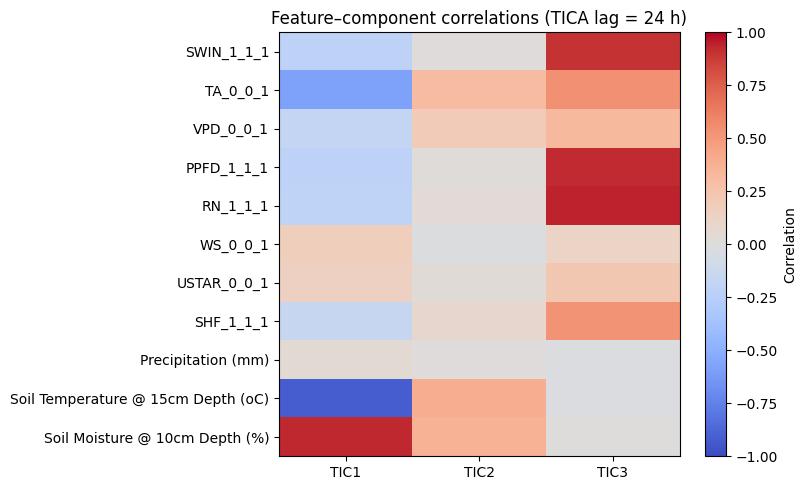


TIC1: strongest absolute feature correlations


,correlation
Soil Moisture @ 10cm Depth (%),0.932631
Soil Temperature @ 15cm Depth (oC),-0.916009
TA_0_0_1,-0.578359
SWIN_1_1_1,-0.218273
PPFD_1_1_1,-0.215973
RN_1_1_1,-0.209847
VPD_0_0_1,-0.178129
WS_0_0_1,0.164823



TIC2: strongest absolute feature correlations


,correlation
Soil Temperature @ 15cm Depth (oC),0.397281
Soil Moisture @ 10cm Depth (%),0.360435
TA_0_0_1,0.306103
VPD_0_0_1,0.188023
SHF_1_1_1,0.082576
RN_1_1_1,0.032401
USTAR_0_0_1,0.024559
PPFD_1_1_1,0.020728



TIC3: strongest absolute feature correlations


,correlation
RN_1_1_1,0.944183
PPFD_1_1_1,0.929504
SWIN_1_1_1,0.902136
TA_0_0_1,0.543385
SHF_1_1_1,0.529096
VPD_0_0_1,0.321398
USTAR_0_0_1,0.225354
WS_0_0_1,0.121140


In [22]:
SELECTED_TICA_LAG = 24
selected_tica = tica_models[SELECTED_TICA_LAG]
n_selected_components = min(N_TICS, selected_tica.feature_component_correlation.shape[1])

TICA_LOADINGS = pd.DataFrame(
    selected_tica.feature_component_correlation[:, :n_selected_components],
    index=TICA_FEATURES,
    columns=[f"TIC{i + 1}" for i in range(n_selected_components)],
)

fig, ax = plt.subplots(figsize=(8, max(5, 0.42 * len(TICA_FEATURES))))
image = ax.imshow(TICA_LOADINGS.to_numpy(), aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(n_selected_components), labels=TICA_LOADINGS.columns)
ax.set_yticks(range(len(TICA_FEATURES)), labels=TICA_FEATURES)
ax.set_title(f"Feature–component correlations (TICA lag = {SELECTED_TICA_LAG} h)")
fig.colorbar(image, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

for component in TICA_LOADINGS.columns:
    print(f"\n{component}: strongest absolute feature correlations")
    display(TICA_LOADINGS[component].sort_values(key=np.abs, ascending=False).head(8).to_frame("correlation"))

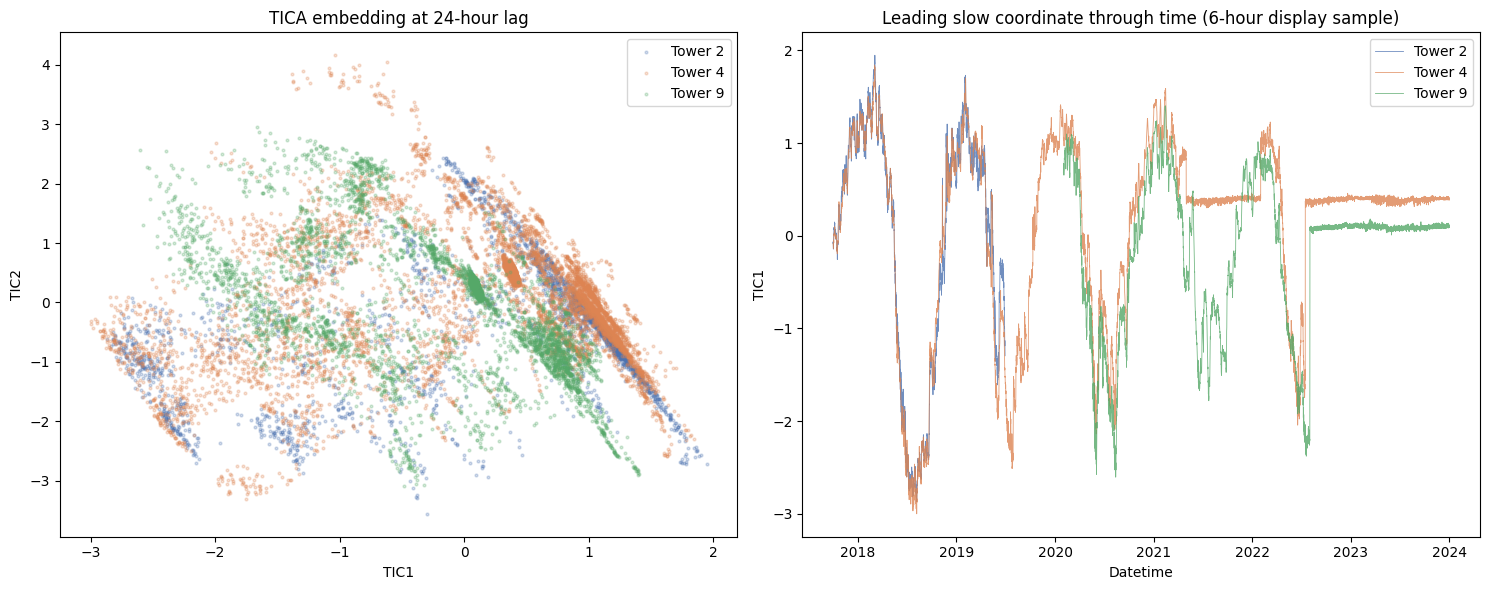

In [23]:
projection_parts = []
for segment in tica_segments:
    projection = selected_tica.transform(segment["X_scaled"])
    projected = pd.DataFrame(
        projection[:, :n_selected_components],
        index=segment["index"],
        columns=[f"TIC{i + 1}" for i in range(n_selected_components)],
    )
    projected["tower"] = segment["tower"]
    projected["segment"] = segment["segment"]
    projection_parts.append(projected)

TICA_PROJECTION = pd.concat(projection_parts).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for tower in TOWERS:
    tower_projection = TICA_PROJECTION.loc[TICA_PROJECTION["tower"].eq(tower)].iloc[::6]
    axes[0].scatter(
        tower_projection["TIC1"], tower_projection["TIC2"],
        s=4, alpha=0.25, color=TOWER_COLORS[tower], label=f"Tower {tower}", rasterized=True
    )
    axes[1].plot(
        tower_projection.index, tower_projection["TIC1"],
        linewidth=0.6, alpha=0.8, color=TOWER_COLORS[tower], label=f"Tower {tower}"
    )

axes[0].set_title(f"TICA embedding at {SELECTED_TICA_LAG}-hour lag")
axes[0].set_xlabel("TIC1")
axes[0].set_ylabel("TIC2")
axes[0].legend()

axes[1].set_title("Leading slow coordinate through time (6-hour display sample)")
axes[1].set_xlabel("Datetime")
axes[1].set_ylabel("TIC1")
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretation checkpoint

Before using TICA components in a gap-filling model, check:

1. whether the leading feature correlations make physical sense;
2. whether implied timescales are reasonably stable across neighbouring lags;
3. whether a component is merely reproducing season, management clocks or tower identity;
4. whether adding fold-fitted TICs improves held-out MAE/RMSE/R2 under the same blocked gap-CV.

The full-data TICA above is EDA. It must not be used directly to claim predictive improvement.

## 5. Gap-filling cross-validation and models

This section turns the EDA into a leakage-safe predictive comparison. It uses **calendar-shaped blocked gaps**, not random missing rows: random-row CV would let adjacent target values and slowly varying environmental states leak information into the test point.

The evaluation keeps every requested prediction, including failed MDS predictions, and reports:

- $R^2$: improvement over predicting the held-out mean (0 = mean baseline; negative = worse);
- RMSE: more sensitive to large errors;
- MAE: typical absolute error in the original FCH4 units;
- MBE: signed bias (`prediction - observation`);
- prediction count and coverage.

Results are kept by tower and gap duration because a model that interpolates a one-hour gap well may not be credible for a twelve-day gap. The longer reusable mechanics are in `section5_gap_filling.py`; the choices, execution and interpretation remain explicit below.

### 5.1 Models and feature arms

The benchmark contains MDS, partially pooled Random Forests, and optional TabICL v2. `met_only11` preserves the original RFm baseline. The compact arms test whether removing width and collinearity recovers the earlier stronger result.

| Feature arm | Purpose |
|---|---|
| `met_only11` | Environmental-sensor RFm baseline |
| `champion30_reference` | Reconstruct the historical compact 30-feature RF |
| `compact24` | Compact environmental, clock, livestock, soil-memory and management set |
| `compact22_no_rad_dupes` | Remove PPFD and RN while retaining SWIN |
| `compact_tica24` | Replace three soil summaries with fold-fitted TIC1–TIC3 |
| `short_memory47` | Add leakage-safe target lags, leads and nearest observations |

The target-memory arm is mainly motivated by short gaps. It is still evaluated over every duration so that its failure boundary is measured rather than assumed. TICs and target-memory variables are reconstructed separately inside every fold.

In [24]:
import sys

section5_module_dir = str(NOTEBOOK_DIR.resolve())
if section5_module_dir not in sys.path:
    sys.path.insert(0, section5_module_dir)

from section5_gap_filling import (
    Section5Benchmark,
    Section5Config,
    plot_section5_diagnostics,
    plot_section5_summary,
)

# Safe notebook defaults. Set RUN_SECTION5=True when ready to start the benchmark.
# RECORD_QUALITY switches 2 -> 20 RF/MDS repetitions and 1 -> 5 TabICL repetitions.
RUN_SECTION5 = True
RUN_TABICL = False
RECORD_QUALITY = False

SECTION5_CONFIG = Section5Config(
    mask_fraction=0.25,
    mds_rf_repetitions=20 if RECORD_QUALITY else 2,
    tabicl_repetitions=5 if RECORD_QUALITY else 1,
    run_tabicl=RUN_TABICL,
    rf_n_estimators=500,
    rf_min_samples_leaf=5,
    rf_max_features=1.0,
    use_model_cache=True,
    tabicl_row_cap=10_000,
    tabicl_feature_arms=("compact24",),
    target_neighbour_horizon=72,
    tica_lag_hours=24,
)

SECTION5_BENCHMARK = Section5Benchmark(
    prepared=prepared,
    domain=DOMAIN,
    output_dir=DATA_DIR,
    cache_dir=CACHE_DIR,
    real_gaps=REAL_GAPS,
    config=SECTION5_CONFIG,
)

SECTION5_RF_ARMS = tuple(SECTION5_BENCHMARK.feature_arms)
SECTION5_FEATURE_AUDIT = SECTION5_BENCHMARK.feature_audit()
display(
    SECTION5_FEATURE_AUDIT.groupby("feature_arm")
    .agg(n_features=("feature", "size"), dynamic_features=("dynamic_inside_fold", "sum"), mean_missing_pct=("missing_pct", "mean"))
    .round(2)
)
print(f"TabICL installed version: {SECTION5_BENCHMARK.tabicl_version() or 'not installed'}")
print(f"RF arms: {SECTION5_RF_ARMS}")

,n_features,dynamic_features,mean_missing_pct
feature_arm,,,
champion30_reference,30,0,0.62
compact22_no_rad_dupes,22,0,0.85
compact24,24,0,0.78
compact_tica24,24,3,0.89
met_only11,11,0,0.00
short_memory47,47,23,0.78


TabICL installed version: 2.1.1
RF arms: ('met_only11', 'champion30_reference', 'compact24', 'compact22_no_rad_dupes', 'compact_tica24', 'short_memory47')


### 5.2 Shared blocked gap folds

Each repetition masks approximately 25% of the *observed* target values using non-overlapping calendar gaps. The scenarios are 1, 4, 32 and 288 hours plus a mixed-duration arm. Every model receives the same held-out timestamps.

For a target tower, its held-out rows are removed from training. Observed rows from the other two towers are retained with explicit tower indicators, giving a target-specific partially pooled fit.

The `short_memory47` arm first masks the fold and only then derives lags/leads and nearest observations. Independent pseudo-gaps are also applied while deriving training features, reducing the difference between ordinary training rows and rows inside a gap. Assertions check that no target-derived input refers to a held-out timestamp.

For `compact_tica24`, environmental variables are median-imputed and standardised separately within each tower using fold-training rows. TICA is fitted to eligible 24-hour pairs without joining tower trajectories, excludes FCH4, and is then used to transform the query rows.

In [25]:
SECTION5_FOLDS = SECTION5_BENCHMARK.build_folds()
SECTION5_FOLD_AUDIT = SECTION5_BENCHMARK.fold_audit()
display(SECTION5_FOLD_AUDIT)

# Basic structural checks before any model is fitted.
assert DATA_AUDIT["absent_rows"].eq(0).all(), "The prepared domain should have no artificial terminal rows."
assert DATA_AUDIT.loc[2, "expected_hours"] == 15_289
assert DATA_AUDIT.loc[4, "expected_hours"] == 54_769
assert DATA_AUDIT.loc[9, "expected_hours"] == 34_297
assert SECTION5_FOLD_AUDIT["held_out_observations"].gt(0).all()
print("Boundary and fold-construction checks passed.")

,tower,scenario,repetition,held_out_observations,unique_synthetic_gaps,mean_gap_length_hours,fold_seed
0,2,l,0,1278,11,288.000000,4066314586
1,2,l,1,1316,11,288.000000,2306019717
2,2,m,0,1224,91,32.000000,2156658643
3,2,m,1,1239,86,32.000000,976242428
4,2,m1,0,1232,53,216.713474,1819972258
5,2,m1,1,1266,52,210.447867,430931399
6,2,s,0,1223,545,4.000000,736660751
7,2,s,1,1222,541,4.000000,537776368
8,2,vs,0,1222,1222,1.000000,430198856
9,2,vs,1,1222,1222,1.000000,3564705424


Boundary and fold-construction checks passed.


### 5.3 Run and retain raw predictions

`RUN_SECTION5=False` prevents an accidental expensive run. When changed to `True`, the development run evaluates MDS and RF across all feature arms using two repetitions. Models are cached by their exact training data, features and parameters.

TabICL is a second explicit opt-in because each fold is substantially more expensive. The installed `tabicl` package is the v2 series; by default it is tested only on `compact24` with a deterministic 10,000-row training cap.

The four saved CSVs are sufficient to recompute all headline metrics without refitting any model.

In [26]:
if RUN_SECTION5:
    SECTION5_RAW_PREDICTIONS = SECTION5_BENCHMARK.run(
        run_mds=True,
        rf_feature_arms=SECTION5_RF_ARMS,
        run_tabicl=RUN_TABICL,
        tabicl_feature_arms=SECTION5_CONFIG.tabicl_feature_arms,
    )
    (
        SECTION5_METRICS_BY_REP,
        SECTION5_SUMMARY,
        SECTION5_FEATURE_AUDIT,
    ) = SECTION5_BENCHMARK.save_results(SECTION5_RAW_PREDICTIONS)
    SECTION5_CHAMPION_CHECK = SECTION5_BENCHMARK.champion_reference_check(SECTION5_SUMMARY)
    display(SECTION5_CHAMPION_CHECK)
    print(f"Saved Section 5 outputs to {DATA_DIR.resolve()}")
else:
    print("Section 5 is configured but not fitted. Set RUN_SECTION5=True and rerun this cell when ready.")

done RF     met_only11               T2 vs rep=0
done RF     champion30_reference     T2 vs rep=0
done RF     compact24                T2 vs rep=0
done RF     compact22_no_rad_dupes   T2 vs rep=0
done RF     compact_tica24           T2 vs rep=0
done RF     short_memory47           T2 vs rep=0
done RF     met_only11               T2 vs rep=1
done RF     champion30_reference     T2 vs rep=1
done RF     compact24                T2 vs rep=1
done RF     compact22_no_rad_dupes   T2 vs rep=1
done RF     compact_tica24           T2 vs rep=1
done RF     short_memory47           T2 vs rep=1
done RF     met_only11               T2 s rep=0
done RF     champion30_reference     T2 s rep=0
done RF     compact24                T2 s rep=0
done RF     compact22_no_rad_dupes   T2 s rep=0
done RF     compact_tica24           T2 s rep=0
done RF     short_memory47           T2 s rep=0
done RF     met_only11               T2 s rep=1
done RF     champion30_reference     T2 s rep=1


KeyboardInterrupt: 

### 5.4 Summaries and diagnostics

The summary contains three views:

1. tower × scenario, preserving the actual CV question;
2. a flat median across scenarios, comparable to earlier notebook headlines;
3. a tower-specific aggregate weighted by the observed number of missing hours in each real gap class. Gaps longer than 288 hours are mapped to the long scenario and the mixed scenario receives zero weight to avoid double counting.

The weighted RMSE is calculated from weighted scenario MSEs. Weighted $R^2$ is a descriptive average of scenario scores rather than a new pooled coefficient of determination.

In [ ]:
if RUN_SECTION5:
    display(
        SECTION5_SUMMARY.loc[
            SECTION5_SUMMARY["aggregate_type"].isin(["flat_scenario_median", "real_gap_hour_weighted"]),
            ["model", "feature_arm", "tower", "aggregate_type", "R2_median", "RMSE_median", "MAE_median", "MBE_median", "coverage_median"],
        ].sort_values(["tower", "aggregate_type", "R2_median"], ascending=[True, True, False])
    )
    plot_section5_summary(SECTION5_SUMMARY)
    plt.show()

In [ ]:
if RUN_SECTION5:
    plot_section5_diagnostics(
        SECTION5_RAW_PREDICTIONS,
        SECTION5_METRICS_BY_REP,
        tower=4,
        scenario="l",
    )
    plt.show()

    # Raw-prediction self-check: recompute the first reported fold without summary tables.
    first_key = ["model", "feature_arm", "tower", "scenario", "repetition"]
    first_values, first_group = next(iter(SECTION5_RAW_PREDICTIONS.groupby(first_key)))
    available = first_group["prediction_available"]
    direct_r2 = r2_score(first_group.loc[available, "y_actual"], first_group.loc[available, "y_pred"])
    reported_r2 = SECTION5_METRICS_BY_REP.set_index(first_key).loc[first_values, "R2"]
    assert np.isclose(direct_r2, reported_r2, equal_nan=True)
    print("Raw-prediction metric self-check passed.")

### 5.5 Reserved extensions

Do not add a hybrid/router until the shared benchmark identifies where each current method succeeds and fails. The same fold table and raw-prediction schema can later be extended with:

- LightGBM and XGBoost as additional tabular learners;
- Bi-LSTM and SAITS as explicitly temporal models;
- provenance-aware features once the upstream export distinguishes observed from gap-filled drivers;
- `gpp_from_observed_fc` once its provenance can be constructed safely.

Those additions must use the identical held-out folds and save raw predictions in the same format. Deep sequence models will also require window-level leakage checks, not only row-level checks.